# Customer Behavior & Segmentation Analysis — ConnectaTel
### Data Analysis Project with Python, Pandas & Data Visualization

**Author:** David Anampa

This project evaluates the customer behavior of ConnectaTel, a Latin American telecommunications company, using usage and subscriber data recorded through 2024.

## Project Overview

ConnectaTel needed a clearer picture of how its customers behave, in order to detect unusual patterns and design meaningful customer segments.

The analysis combines three datasets:

- **plans.csv** — current plan details (price, included minutes, included GB, extra usage cost)
- **users_latam.csv** — customer information (age, city, registration date, plan, churn date)
- **usage.csv** — actual service usage detail (calls and text messages)

The workflow includes:

- Data exploration and validation
- Data quality assessment (missing values, sentinel values, invalid dates)
- Data cleaning
- Usage aggregation and customer profile construction
- Distribution analysis and outlier detection
- Customer segmentation by usage level and age
- Business interpretation of findings

This analysis supports identifying consumption patterns, designing retention strategies, and suggesting improvements to the plans offered by the company.

## 1. Data Loading & Initial Exploration

The first stage focuses on importing the three datasets and validating their structure, data types, and overall quality before preprocessing.

In [2]:
# importar librerías
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
# load files
plans = pd.read_csv('datasets/plans.csv')
users = pd.read_csv('datasets/users_latam.csv')
usage = pd.read_csv('datasets/usage.csv')

In [4]:
# mostrar las primeras filas
# show the first rows
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [7]:
# revisar el número de filas y columnas de cada dataset
# check the number of rows and columns of each dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


## 2. Data Quality Assessment

### 2.1 Missing Values

In [11]:
# cantidad de nulos para users
# missing values for users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
# missing values for usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Diagnosis — missing values**

- `city` shows 11.73% missing values; its source should be investigated and possible imputation evaluated as part of the cleaning stage.
- `churn_date` shows 88.35% missing values, but these likely represent customers who have not yet cancelled the service, so they will be kept as-is.
- `date` (in `usage`) shows only 0.125% missing values, a negligible impact; those records could be dropped if needed.
- `duration` (55.19%) and `length` (44.74%) show a high proportion of missing values, likely because each variable only applies to one type of activity (call vs. text). This is investigated further below before deciding how to treat them.

### 2.2 Invalid Values & Sentinels

In [13]:
# explorar columnas numéricas de users
# explore numeric columns in users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


**Diagnosis — users (numeric)**

- `user_id` contains unique customer identifiers, ranging from 10000 to 13999 with no apparent anomalies.
- `age` has a reasonable maximum (79), but the minimum is **-999**, indicating a sentinel value used to represent missing or unknown data. The unusually high standard deviation (123.23) is also driven by this outlier. This should be investigated and corrected before continuing the analysis.

In [14]:
# explorar columnas numéricas de usage
# explore numeric columns in usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


**Diagnosis — usage (numeric)**

- `id` and `user_id` are record and user identifiers respectively; they show no evident outliers and are used only for identification and joining tables.
- `duration` shows a right-skewed distribution: most call durations are relatively short, but calls of up to 120 minutes exist and could represent valid outliers.
- `length` (message length) is also right-skewed, with a median of 50 and a maximum of 1,490 — well above the third quartile (64) — suggesting the presence of extreme values that warrant closer inspection.

In [15]:
# explorar columnas categóricas de users
# explore categorical columns in users
user_categorical_cols = users[['city', 'plan']]

for col in user_categorical_cols:
    print(f'\n{col}')
    print(users[col].value_counts(dropna=False))


city
city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

plan
plan
Basico     2595
Premium    1405
Name: count, dtype: int64


**Diagnosis — users (categorical)**

- `city` contains several registered cities, but has 469 missing values and 96 records with the value `"?"`, which likely represents missing or unknown data. `"?"` should be treated as a missing value during cleaning.
- `plan` contains only two categories (Basic and Premium) with no missing values or apparent inconsistencies, so it likely requires no further cleaning.

In [16]:
# explorar columna categórica de usage
# explore categorical column in usage
usage['type'].value_counts(dropna=False)

type
text    22092
call    17908
Name: count, dtype: int64

**Diagnosis — usage (categorical)**

- `type` contains two categories (`text` and `call`) with no missing values. The distribution shows a slight predominance of text messages over calls.

**Summary of invalid values found**
- `age` contains the sentinel value **-999**, used to represent missing or unknown data — it will be replaced with `NaN` for proper treatment.
- `city` contains the sentinel value `"?"`, which also appears to represent missing data — it will be replaced with `NaN` to unify how missing values are handled.
- No other clear invalid values or sentinels were identified in the remaining columns explored.

### 2.3 Date Validation & Standardization

In [17]:
# convertir a fecha la columna reg_date de users
# convert the reg_date column in users to datetime
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [18]:
# convertir a fecha la columna date de usage
# convert the date column in usage to datetime
usage['date'] = pd.to_datetime(usage['date'])

In [19]:
# revisar los años presentes en reg_date de users
# check the years present in reg_date (users)
users['reg_date'].dt.year.value_counts().sort_index()

reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64

`reg_date` records span 2022, 2023, and 2024, all within a reasonable time range for this dataset — no out-of-range years are identified.

In [20]:
# revisar los años presentes en date de usage
# check the years present in date (usage)
usage['date'].dt.year.value_counts(dropna=False).sort_index()

date
2024.0    39950
NaN          50
Name: count, dtype: int64

`date` (in `usage`) corresponds mainly to 2024. No dates outside the expected range are identified, although some missing values remain to be considered during the analysis.

**Diagnosis — date validation**
- `reg_date` shows dates within 2022–2024, a reasonable time range for this dataset.
- `date` shows records from 2024, with no evidence of impossible or future years.
- No out-of-range dates were identified, so no corrective action is required beyond the type conversion already applied.

## 3. Data Cleaning

### 3.1 Correcting Sentinels & Invalid Dates

In [22]:
# reemplazar -999 por la mediana de age
# replace -999 with the median of age
age_median = users['age'].median()
users['age'] = users['age'].replace(-999, age_median)

# verificar cambios
# verify changes
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# reemplazar "?" por NA en city
# replace "?" with NA in city
users['city'] = users['city'].replace('?', np.nan)

# verificar cambios
# verify changes
users['city'].value_counts(dropna=False)

city
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64

In [24]:
# marcar fechas futuras como NA en reg_date
# mark future dates as NA in reg_date
users.loc[users['reg_date'] > pd.Timestamp.now(), 'reg_date'] = pd.NaT

# verificar cambios
# verify changes
users['reg_date'].describe()

count                             4000
mean     2023-07-14 07:31:29.284321280
min                2022-01-01 00:00:00
25%      2022-10-05 14:00:10.802700800
50%      2023-07-09 21:26:03.690922752
75%      2024-04-11 15:43:20.750187520
max                2026-05-10 00:00:00
Name: reg_date, dtype: object

### 3.2 Missing Values in Usage Metrics

In [25]:
# verificación MAR en usage (Missing At Random) para duration
# MAR check (Missing At Random) for duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [26]:
# verificación MAR en usage (Missing At Random) para length
# MAR check (Missing At Random) for length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Diagnosis — missing usage metrics**

Missing values in `duration` and `length` follow a clear pattern related to `type`: almost all `text` records are missing `duration`, while almost all `call` records are missing `length`. This means the missing values are not random — they simply represent a metric that does not apply to that type of activity (a text message has no call duration, and a call has no message length). These values are therefore kept as `NaN` rather than imputed, since imputing them would introduce meaningless data.

## 4. Usage Aggregation & Customer Profile Construction

### 4.1 Grouping Usage Behavior by Customer

The `usage` table is summarized at the customer level, building metrics that represent each customer's real historical usage.

In [27]:
# columnas auxiliares
# helper columns
usage["is_text"] = (usage["type"] == "text").astype(int)  # to count total messages
usage["is_call"] = (usage["type"] == "call").astype(int)  # to count total calls

# agrupar información por usuario
# aggregate information per user
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum",
}).reset_index()

# observar resultado
# check the result
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# renombrar columnas
# rename columns
usage_agg = usage_agg.rename(columns={
    "is_text": "num_messages",
    "is_call": "num_calls",
    "duration": "call_minutes"
})
# observar resultado
# check the result
usage_agg.head(3)

,user_id,num_messages,num_calls,call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# combinar la tabla agregada con el dataset de usuarios
# merge the aggregated table with the users dataset
user_profile = pd.merge(users, usage_agg, on='user_id')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,num_messages,num_calls,call_minutes
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 Statistical Summary of Customer Profiles (2024)

In [30]:
# resumen estadístico de las columnas numéricas
# descriptive statistics for the numeric columns
user_profile[['age', 'num_messages', 'num_calls', 'call_minutes']].describe()

,age,num_messages,num_calls,call_minutes
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# distribución porcentual del tipo de plan
# percentage distribution of plan type
user_profile['plan'].value_counts(normalize=True) * 100

plan
Basico     64.866217
Premium    35.133783
Name: proportion, dtype: float64

## 5. Distribution Analysis & Outlier Detection

### 5.1 Visualizing Distributions

Histograms are used to understand how the key usage and customer variables behave, and to observe the shape of each distribution.

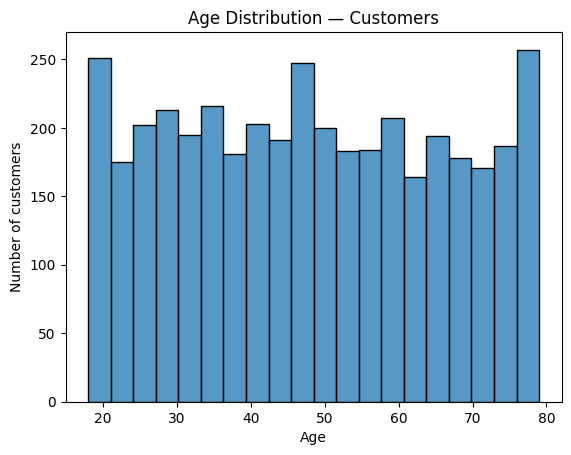

In [30]:
# histograma para visualizar la edad (age)
# histogram to visualize age
sns.histplot(user_profile['age'], bins=20)

plt.title('Age Distribution — Customers')
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.show()

**Insight:** the age distribution is relatively uniform across customers, with a higher concentration in adult age ranges and no presence of outliers.

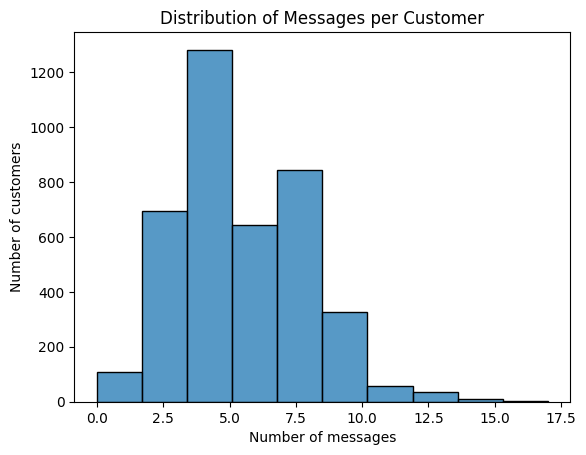

In [31]:
# histograma para visualizar num_messages
# histogram to visualize num_messages
sns.histplot(user_profile['num_messages'], bins=10)

plt.title('Distribution of Messages per Customer')
plt.xlabel('Number of messages')
plt.ylabel('Number of customers')
plt.show()

**Insight:** most customers send between 3 and 8 messages, with few customers sending significantly more, showing a distribution slightly skewed to the right.

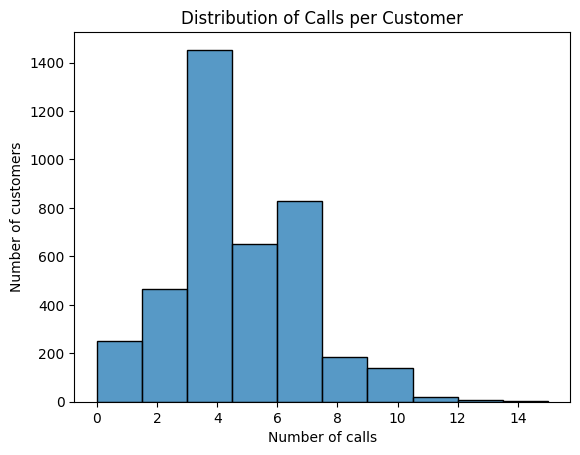

In [32]:
# histograma para visualizar num_calls
# histogram to visualize num_calls
sns.histplot(user_profile['num_calls'], bins=10)

plt.title('Distribution of Calls per Customer')
plt.xlabel('Number of calls')
plt.ylabel('Number of customers')
plt.show()

**Insight:** the number of calls is concentrated mainly between 3 and 7 calls per customer, with few cases of customers with a higher calling frequency.

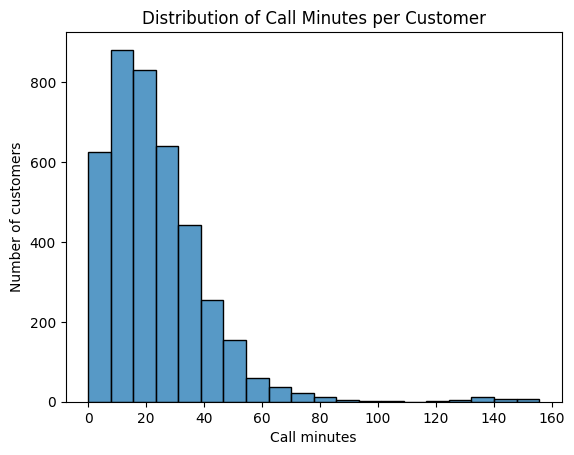

In [33]:
# histograma para visualizar call_minutes
# histogram to visualize call_minutes
sns.histplot(user_profile['call_minutes'], bins=20)

plt.title('Distribution of Call Minutes per Customer')
plt.xlabel('Call minutes')
plt.ylabel('Number of customers')
plt.show()

**Insight:** most customers consume relatively few call minutes, while a tail toward higher values exists due to a small number of customers with heavy usage.

### 5.2 Outlier Identification

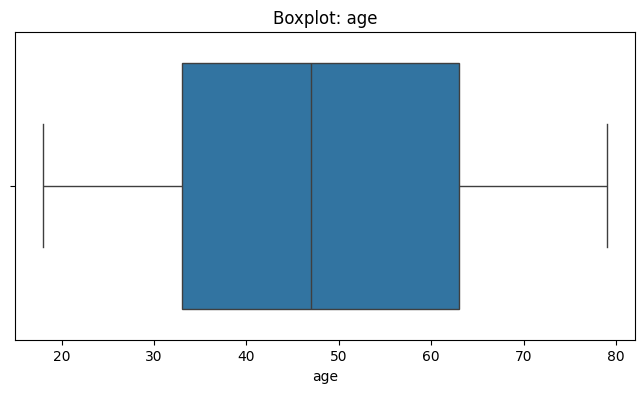

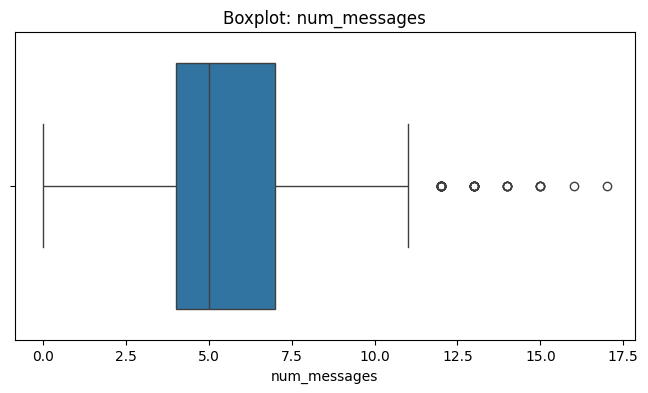

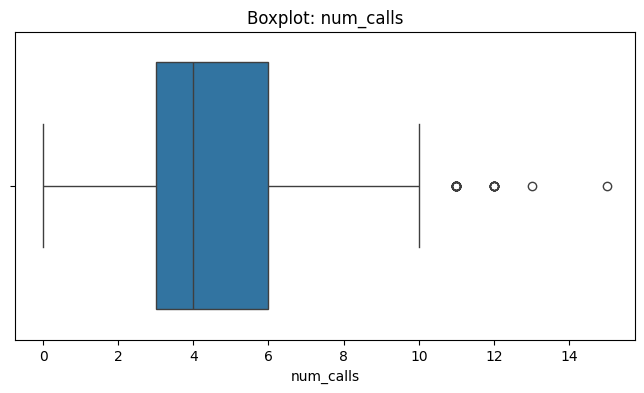

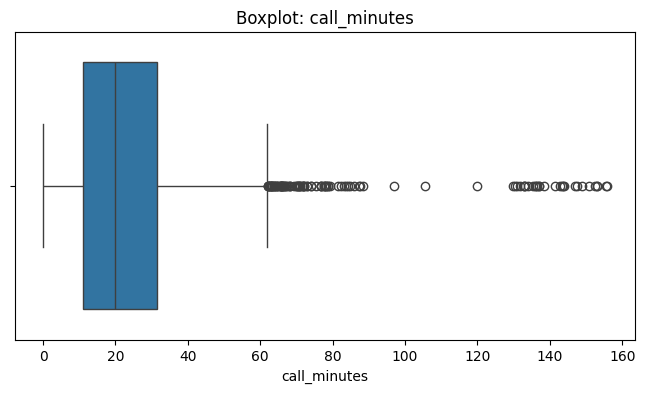

In [34]:
# visualizando usando boxplot
# visualizing using boxplot
numeric_cols = ['age', 'num_messages', 'num_calls', 'call_minutes']

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

**Insight**
- `age`: no significant outliers after correcting the -999 sentinel value.
- `num_messages`: some outliers from customers with a high number of messages.
- `num_calls`: few outliers associated with customers with a high number of calls.
- `call_minutes`: several outliers due to customers with considerably higher-than-average minute consumption.

In [31]:
# calcular límites con el método IQR
# calculate limits using the IQR method
limit_cols = ['num_messages', 'num_calls', 'call_minutes']

for col in limit_cols:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1

    upper_limit = q3 + 1.5 * iqr

    print(f'{col}:')
    print(f'Upper limit: {upper_limit}')
    print(f'Current max: {user_profile[col].max()}')
    print()

num_messages:
Upper limit: 11.5
Current max: 17

num_calls:
Upper limit: 10.5
Current max: 15

call_minutes:
Upper limit: 61.8575
Current max: 155.69



In [32]:
# revisar los límites superiores y el máximo, para decidir si mantener los outliers
# review the upper limits and the max, to decide whether to keep the outliers
user_profile[limit_cols].describe()

,num_messages,num_calls,call_minutes
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


**Insight — keep or remove outliers?**
- `num_messages`: outliers are kept, since they represent customers with heavy messaging usage rather than data errors.
- `num_calls`: outliers are kept, as they reflect customers with a higher number of calls that may be genuine behavior.
- `call_minutes`: outliers are kept, since they represent customers with high minute consumption and can provide relevant information for the analysis.

## 6. Customer Segmentation

### 6.1 Segmentation by Usage Level

Each customer is classified into a usage group (Low, Medium, High) based on the number of calls and messages recorded.

In [33]:
# crear columna usage_group
# create usage_group column
def usage_group(row):
    if row['num_calls'] < 5 and row['num_messages'] < 5:
        return 'Low usage'
    elif row['num_calls'] < 10 and row['num_messages'] < 10:
        return 'Medium usage'
    else:
        return 'High usage'

user_profile['usage_group'] = user_profile.apply(usage_group, axis=1)

In [34]:
# verificar cambios
# verify changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,num_messages,num_calls,call_minutes,usage_group
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Medium usage
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,High usage
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Medium usage
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,High usage
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Low usage


### 6.2 Segmentation by Age

In [35]:
# crear columna age_group
# create age_group column
def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

user_profile['age_group'] = user_profile['age'].apply(age_group)

In [36]:
# verificar cambios
# verify changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,num_messages,num_calls,call_minutes,usage_group,age_group
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Medium usage,Adult
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,High usage,Adult
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Medium usage,Adult
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,High usage,Senior
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Low usage,Senior


### 6.3 Visualizing Customer Segments

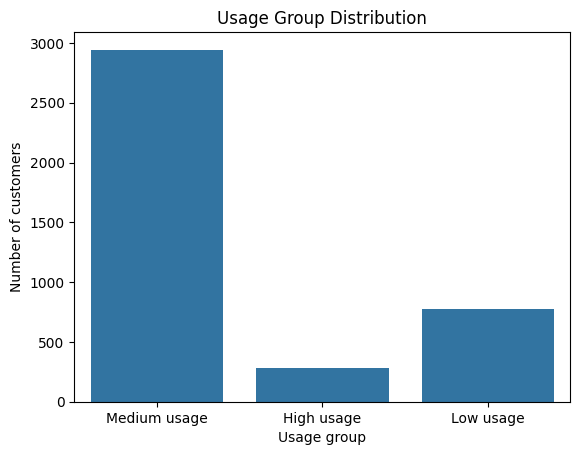

In [37]:
# visualización de los segmentos por uso
# visualization of usage segments
sns.countplot(data=user_profile, x='usage_group')

plt.title('Usage Group Distribution')
plt.xlabel('Usage group')
plt.ylabel('Number of customers')
plt.show()

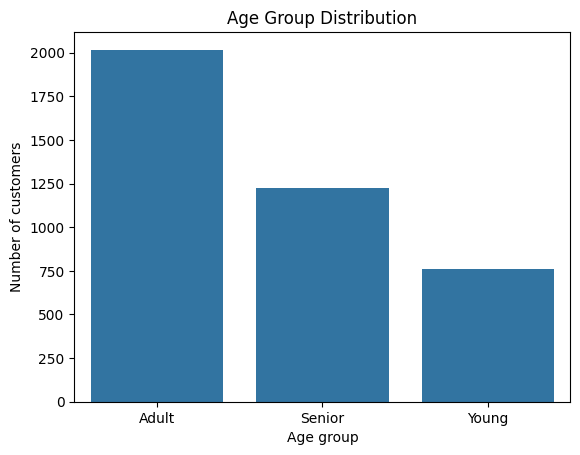

In [42]:
# visualización de los segmentos por edad
# visualization of age segments
sns.countplot(data=user_profile, x='age_group')

plt.title('Age Group Distribution')
plt.xlabel('Age group')
plt.ylabel('Number of customers')
plt.show()

## 7. Executive Insight for Stakeholders

The findings from the analysis are translated into actionable business conclusions, focused on segmentation, usage patterns, and commercial opportunities.

**Questions addressed**
- What data quality issues were found, and how significant were they?
- Which customer segments show more relevant or profitable behavior?
- What business strategies can be derived from the segments identified?

### Executive Analysis

**⚠️ Data issues detected**
- Invalid values such as -999 were found in `age`, unknown values (`?`) in `city`, and missing values in usage variables.
- Missing values in `duration` and `length` depended on the record type, so they were kept as `NaN` since they represented cases where the variable did not apply.

**🔍 Age segments**
- Customers show a fairly balanced distribution across age ranges, with adults and seniors predominating.
- No extreme behavioral differences were identified based on age alone.

**📊 Usage-level segments**
- Most customers fall into the medium-usage segment, while high- and low-usage groups represent a smaller share.
- High-usage customers stand out for a higher number of calls and messages, representing customers with greater consumption potential.

**➡️** This suggests ConnectaTel can focus differentiated strategies by activity level, offering benefits designed to increase retention and monetization of its user base.

**💡 Recommendations**
- Create personalized plans for high-usage customers with greater call and data benefits.
- Encourage low-usage customers through promotions designed to increase their consumption.
- Maintain loyalty strategies for medium-usage customers, since they represent the largest share of the customer base.
- Investigate high-consumption outliers as potential premium customers or users with specific needs.